# DBSCAN Clustering Analysis

## Objective
Apply DBSCAN (Density-Based Spatial Clustering of Applications with Noise) clustering to student performance data across three academic years to identify natural groupings based on student characteristics and performance metrics.

## Methodology
1. Data Preparation and Feature Selection
2. Feature Scaling using StandardScaler
3. Parameter Optimization using k-distance graph
4. DBSCAN Application and Evaluation
5. Suitability Assessment for each year's data


In [ ]:
# =============================================================================
# Import Required Libraries
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Scikit-learn imports for clustering
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# =============================================================================
# Load Data
# =============================================================================
data_1y = pd.read_csv('../data/1y_final_clean_encoded.csv')
data_2y = pd.read_csv('../data/2y_final_clean_encoded.csv')
data_3y = pd.read_csv('../data/3y_final_clean_encoded.csv')

print("=" * 60)
print("DATA LOADING SUMMARY")
print("=" * 60)
print(f"\n{'Dataset':<15} {'Rows':<10} {'Columns':<10}")
print("-" * 35)
print(f"{'1st Year':<15} {data_1y.shape[0]:<10} {data_1y.shape[1]:<10}")
print(f"{'2nd Year':<15} {data_2y.shape[0]:<10} {data_2y.shape[1]:<10}")
print(f"{'3rd Year':<15} {data_3y.shape[0]:<10} {data_3y.shape[1]:<10}")
print("\nData loaded successfully.")

data_2y.head()

DATA LOADING SUMMARY

Dataset         Rows       Columns   
-----------------------------------
1st Year        210        57        
2nd Year        101        64        
3rd Year        12         49        

Data loaded successfully.


,record_id,gender,study_year,bac_specialty,study_hours_per_week,preferred_study_place,preferred_study_time,learning_methods,study_resources,uses_planner,...,2y complexity,2y proba stat ii,2y lin alg ii,2y intro ai,2y oper res,2y archi ii,2y oper syst,2y soft eng,2y web prog,2y intro busin
0,4,1,1,0,0,1,2,46,29,0,...,1,1,2,1,1,2,2,1,2,0
1,6,0,2,0,0,1,0,16,27,1,...,1,1,2,1,1,2,2,1,2,0
2,12,1,1,0,0,1,1,17,29,0,...,1,1,2,1,1,2,2,1,2,0
3,18,1,2,0,0,1,0,0,14,0,...,1,1,2,1,1,2,2,1,2,0
4,28,0,1,1,1,1,0,45,20,1,...,1,1,2,1,1,2,2,1,2,0


## 1. Data Exploration and Understanding

In [3]:
# =============================================================================
# Explore Data Structure and Identify Feature Types
# =============================================================================

def explore_dataset(df, name):
    """Comprehensive dataset exploration function."""
    print(f"\n{'='*60}")
    print(f"DATASET: {name}")
    print(f"{'='*60}")
    
    print(f"\nShape: {df.shape[0]} rows x {df.shape[1]} columns")
    
    # Identify numeric and categorical columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    
    print(f"\nNumeric columns: {len(numeric_cols)}")
    print(f"Categorical columns: {len(categorical_cols)}")
    
    # Check for missing values
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(f"\nMissing values detected:")
        print(missing[missing > 0])
    else:
        print(f"\nNo missing values")
    
    # Display basic statistics
    print(f"\nStatistical Summary:")
    display(df.describe().round(2))
    
    return numeric_cols, categorical_cols

# Explore all datasets
print("\n" + "="*80)
print("DATA EXPLORATION")
print("="*80)

numeric_1y, categorical_1y = explore_dataset(data_1y, "1st Year Students")
numeric_2y, categorical_2y = explore_dataset(data_2y, "2nd Year Students")
numeric_3y, categorical_3y = explore_dataset(data_3y, "3rd Year Students")


DATA EXPLORATION

DATASET: 1st Year Students

Shape: 210 rows x 57 columns

Numeric columns: 57
Categorical columns: 0

No missing values

Statistical Summary:


,record_id,gender,study_year,bac_specialty,study_hours_per_week,preferred_study_place,preferred_study_time,learning_methods,study_resources,uses_planner,...,1y english 2,1y intensive english,1y seminar,1y analysis i,1y algebra,1y a com i,1y intro prog c,1y analysis ii,1y a com ii,1y proba stat
count,210.00,210.00,210.00,210.00,210.00,210.00,210.00,210.00,210.00,210.00,...,210.00,210.00,210.00,210.00,210.00,210.00,210.0,210.00,210.00,210.00
mean,105.50,0.45,2.06,0.58,1.17,2.20,0.28,25.80,20.15,0.38,...,1.12,0.96,0.42,0.47,0.55,0.80,1.1,1.05,1.06,1.22
std,60.77,0.50,0.54,0.66,1.31,1.07,0.56,17.08,11.91,0.49,...,1.36,1.00,0.80,0.50,0.73,1.08,1.2,0.94,0.97,1.14
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
25%,53.25,0.00,2.00,0.00,0.00,2.00,0.00,11.00,10.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
50%,105.50,0.00,2.00,0.00,1.00,3.00,0.00,24.50,19.50,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.5,1.00,2.00,1.00
75%,157.75,1.00,2.00,1.00,2.00,3.00,0.00,40.00,31.00,1.00,...,2.00,2.00,0.00,1.00,1.00,2.00,2.0,2.00,2.00,2.00
max,210.00,1.00,3.00,2.00,5.00,3.00,2.00,57.00,40.00,1.00,...,4.00,2.00,2.00,1.00,2.00,3.00,3.0,2.00,2.00,4.00



DATASET: 2nd Year Students

Shape: 101 rows x 64 columns

Numeric columns: 64
Categorical columns: 0

No missing values

Statistical Summary:


,record_id,gender,study_year,bac_specialty,study_hours_per_week,preferred_study_place,preferred_study_time,learning_methods,study_resources,uses_planner,...,2y complexity,2y proba stat ii,2y lin alg ii,2y intro ai,2y oper res,2y archi ii,2y oper syst,2y soft eng,2y web prog,2y intro busin
count,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,...,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00
mean,238.80,0.43,1.67,0.50,0.80,1.42,0.32,22.56,17.08,0.35,...,0.82,0.85,1.57,1.19,1.14,1.47,1.40,0.66,1.48,0.10
std,139.72,0.50,0.68,0.74,1.16,0.77,0.58,15.55,9.81,0.48,...,0.48,0.38,0.82,0.50,0.66,0.90,1.01,0.52,0.88,0.41
min,4.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,119.00,0.00,2.00,0.00,0.00,1.00,0.00,7.00,8.00,0.00,...,1.00,1.00,2.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
50%,210.00,0.00,2.00,0.00,0.00,2.00,0.00,23.00,20.00,0.00,...,1.00,1.00,2.00,1.00,1.00,2.00,2.00,1.00,2.00,0.00
75%,364.00,1.00,2.00,1.00,1.00,2.00,1.00,36.00,25.00,1.00,...,1.00,1.00,2.00,1.00,2.00,2.00,2.00,1.00,2.00,0.00
max,475.00,1.00,2.00,2.00,5.00,2.00,2.00,49.00,32.00,1.00,...,2.00,2.00,2.00,2.00,2.00,3.00,3.00,2.00,2.00,2.00



DATASET: 3rd Year Students

Shape: 12 rows x 49 columns

Numeric columns: 49
Categorical columns: 0

No missing values

Statistical Summary:


,record_id,gender,study_year,bac_specialty,study_hours_per_week,preferred_study_place,preferred_study_time,learning_methods,study_resources,uses_planner,...,3y stochastic,3y software engineering,3y networks and protocols,3y mobile development,3y entrepreneurship and innovation,3y machine learning,3y numerical methods and optimisation,3y time series,3y advanced databases,3y computer and network security
count,12.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00,...,12.00,12.00,12.0,12.00,12.00,12.0,12.00,12.00,12.00,12.00
mean,119.58,0.33,0.08,0.42,0.58,1.58,0.17,5.33,4.17,0.58,...,0.92,0.25,1.0,0.25,0.17,0.0,0.75,0.75,0.67,0.33
std,49.28,0.49,0.29,0.51,0.79,0.79,0.39,3.37,2.79,0.51,...,0.29,0.45,0.6,0.45,0.39,0.0,0.97,1.06,0.49,0.49
min,45.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.00,0.00,0.00
25%,83.00,0.00,0.00,0.00,0.00,1.75,0.00,2.75,1.75,0.00,...,1.00,0.00,1.0,0.00,0.00,0.0,0.00,0.00,0.00,0.00
50%,112.50,0.00,0.00,0.00,0.00,2.00,0.00,5.50,4.50,1.00,...,1.00,0.00,1.0,0.00,0.00,0.0,0.00,0.00,1.00,0.00
75%,147.25,1.00,0.00,1.00,1.00,2.00,0.00,8.25,6.25,1.00,...,1.00,0.25,1.0,0.25,0.00,0.0,2.00,1.25,1.00,1.00
max,210.00,1.00,1.00,1.00,2.00,2.00,1.00,10.00,8.00,1.00,...,1.00,1.00,2.0,1.00,1.00,0.0,2.00,3.00,1.00,1.00


In [4]:
# =============================================================================
# Identify Common Features Across All Years for Clustering
# =============================================================================

# Define feature categories
demographic_features = ['gender', 'bac_specialty']

study_habit_features = ['study_hours_per_week', 'preferred_study_place', 'preferred_study_time',
                        'learning_methods', 'study_resources', 'uses_planner']

self_assessment_features = ['english_level', 'programming_level', 'computer_science_level', 
                            'mathematics_level']

wellbeing_features = ['motivation_level', 'sleep_hours', 'stress_management', 
                      'program_satisfaction', 'external_activities']

# Common features present in all datasets for clustering
common_features = demographic_features + study_habit_features + self_assessment_features + wellbeing_features

print("="*60)
print("FEATURE SELECTION FOR CLUSTERING")
print("="*60)
print(f"\nSelected {len(common_features)} common features across all years:")
print(f"\n1. Demographic Features ({len(demographic_features)}):")
for f in demographic_features:
    print(f"   - {f}")
print(f"\n2. Study Habit Features ({len(study_habit_features)}):")
for f in study_habit_features:
    print(f"   - {f}")
print(f"\n3. Self-Assessment Features ({len(self_assessment_features)}):")
for f in self_assessment_features:
    print(f"   - {f}")
print(f"\n4. Wellbeing Features ({len(wellbeing_features)}):")
for f in wellbeing_features:
    print(f"   - {f}")

# Verify all features exist in each dataset
for name, df in [('1st Year', data_1y), ('2nd Year', data_2y), ('3rd Year', data_3y)]:
    missing_features = [f for f in common_features if f not in df.columns]
    if missing_features:
        print(f"\n{name} missing features: {missing_features}")
    else:
        print(f"\n{name}: All common features present")

FEATURE SELECTION FOR CLUSTERING

Selected 17 common features across all years:

1. Demographic Features (2):
   - gender
   - bac_specialty

2. Study Habit Features (6):
   - study_hours_per_week
   - preferred_study_place
   - preferred_study_time
   - learning_methods
   - study_resources
   - uses_planner

3. Self-Assessment Features (4):
   - english_level
   - programming_level
   - computer_science_level
   - mathematics_level

4. Wellbeing Features (5):
   - motivation_level
   - sleep_hours
   - stress_management
   - program_satisfaction
   - external_activities

1st Year: All common features present

2nd Year: All common features present

3rd Year: All common features present


## 2. Data Preparation for DBSCAN

In [5]:
# =============================================================================
# Prepare Data for Clustering
# =============================================================================

def prepare_clustering_data(df, features, dataset_name):
    """
    Prepare data for DBSCAN clustering:
    1. Select relevant features
    2. Handle any remaining missing values
    3. Standardize features
    """
    print(f"\n{'='*60}")
    print(f"PREPARING: {dataset_name}")
    print(f"{'='*60}")
    
    # Select features
    X = df[features].copy()
    print(f"\nSelected {len(features)} features")
    
    # Handle missing values if any
    if X.isnull().sum().sum() > 0:
        print(f"\nHandling {X.isnull().sum().sum()} missing values with median imputation")
        X = X.fillna(X.median())
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    print(f"\nFeatures standardized (mean=0, std=1)")
    print(f"Scaled data shape: {X_scaled.shape}")
    
    return X, X_scaled, scaler

# Prepare all datasets
X_1y, X_1y_scaled, scaler_1y = prepare_clustering_data(data_1y, common_features, "1st Year")
X_2y, X_2y_scaled, scaler_2y = prepare_clustering_data(data_2y, common_features, "2nd Year")
X_3y, X_3y_scaled, scaler_3y = prepare_clustering_data(data_3y, common_features, "3rd Year")

print("\n" + "="*60)
print("DATA PREPARATION SUMMARY")
print("="*60)
print(f"\n{'Dataset':<15} {'Samples':<12} {'Features':<12}")
print("-" * 39)
print(f"{'1st Year':<15} {X_1y_scaled.shape[0]:<12} {X_1y_scaled.shape[1]:<12}")
print(f"{'2nd Year':<15} {X_2y_scaled.shape[0]:<12} {X_2y_scaled.shape[1]:<12}")
print(f"{'3rd Year':<15} {X_3y_scaled.shape[0]:<12} {X_3y_scaled.shape[1]:<12}")


PREPARING: 1st Year

Selected 17 features

Features standardized (mean=0, std=1)
Scaled data shape: (210, 17)

PREPARING: 2nd Year

Selected 17 features

Features standardized (mean=0, std=1)
Scaled data shape: (101, 17)

PREPARING: 3rd Year

Selected 17 features

Features standardized (mean=0, std=1)
Scaled data shape: (12, 17)

DATA PREPARATION SUMMARY

Dataset         Samples      Features    
---------------------------------------
1st Year        210          17          
2nd Year        101          17          
3rd Year        12           17          


## 2.1 Data Distribution Before Clustering

Visualize the data structure and pairwise distances to understand the inherent data shape before applying DBSCAN.

In [6]:
# =============================================================================
# Pairwise Distance Analysis
# =============================================================================
from scipy.spatial.distance import pdist, squareform

def analyze_pairwise_distances(X_scaled, dataset_name):
    """
    Compute and visualize pairwise distance distribution.
    """
    # Calculate pairwise Euclidean distances
    distances = pdist(X_scaled, metric='euclidean')
    
    print(f"\n{'='*60}")
    print(f"PAIRWISE DISTANCE ANALYSIS: {dataset_name}")
    print(f"{'='*60}")
    print(f"\nNumber of pairwise distances: {len(distances)}")
    print(f"\nDistance Statistics:")
    print(f"   Min:    {distances.min():.3f}")
    print(f"   Max:    {distances.max():.3f}")
    print(f"   Mean:   {distances.mean():.3f}")
    print(f"   Std:    {distances.std():.3f}")
    print(f"   Median: {np.median(distances):.3f}")
    
    return distances

# Analyze pairwise distances for all datasets
dist_1y = analyze_pairwise_distances(X_1y_scaled, "1st Year Students")
dist_2y = analyze_pairwise_distances(X_2y_scaled, "2nd Year Students")
dist_3y = analyze_pairwise_distances(X_3y_scaled, "3rd Year Students")


PAIRWISE DISTANCE ANALYSIS: 1st Year Students

Number of pairwise distances: 21945

Distance Statistics:
   Min:    1.541
   Max:    10.189
   Mean:   5.740
   Std:    1.104
   Median: 5.686

PAIRWISE DISTANCE ANALYSIS: 2nd Year Students

Number of pairwise distances: 5050

Distance Statistics:
   Min:    1.734
   Max:    10.844
   Mean:   5.749
   Std:    1.133
   Median: 5.690

PAIRWISE DISTANCE ANALYSIS: 3rd Year Students

Number of pairwise distances: 66

Distance Statistics:
   Min:    3.752
   Max:    8.419
   Mean:   6.013
   Std:    0.965
   Median: 6.043


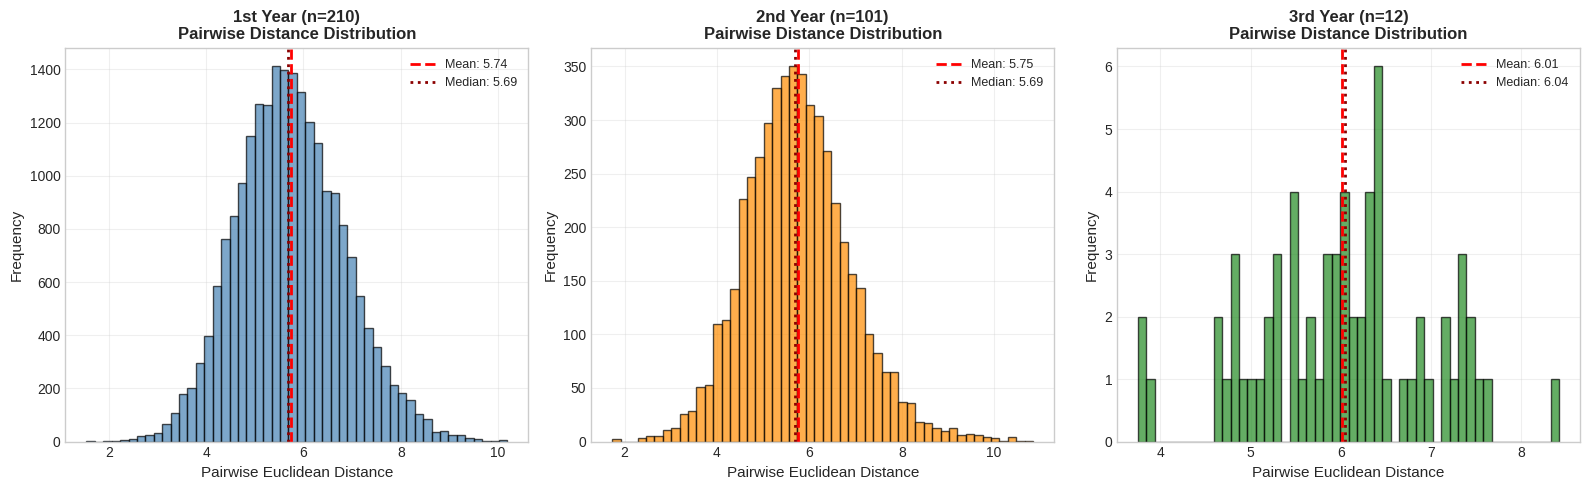


Interpretation:
   - Distance distributions indicate data spread and density characteristics
   - Narrow distributions suggest more compact data; wide distributions indicate dispersed data
   - These statistics inform epsilon (eps) parameter selection for DBSCAN


In [7]:
# =============================================================================
# Visualize Pairwise Distance Distributions
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, distances, name, color in zip(
    axes, 
    [dist_1y, dist_2y, dist_3y], 
    ['1st Year (n=210)', '2nd Year (n=101)', '3rd Year (n=12)'],
    ['steelblue', 'darkorange', 'forestgreen']
):
    ax.hist(distances, bins=50, color=color, edgecolor='black', alpha=0.7)
    ax.axvline(np.mean(distances), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(distances):.2f}')
    ax.axvline(np.median(distances), color='darkred', linestyle=':', linewidth=2, label=f'Median: {np.median(distances):.2f}')
    ax.set_xlabel('Pairwise Euclidean Distance', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{name}\nPairwise Distance Distribution', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("   - Distance distributions indicate data spread and density characteristics")
print("   - Narrow distributions suggest more compact data; wide distributions indicate dispersed data")
print("   - These statistics inform epsilon (eps) parameter selection for DBSCAN")

In [8]:
# =============================================================================
# Data Shape Visualization Using PCA (Before Clustering)
# =============================================================================

def visualize_data_before_clustering(X_scaled, dataset_name, n_samples):
    """
    Visualize data distribution using PCA before any clustering is applied.
    """
    # Apply PCA for visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot of all data points
    axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c='steelblue', s=50, alpha=0.6, 
                   edgecolors='black', linewidth=0.5)
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
    axes[0].set_title(f'{dataset_name} (n={n_samples})\nData Distribution Before Clustering', 
                     fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Density plot using hexbin
    hb = axes[1].hexbin(X_pca[:, 0], X_pca[:, 1], gridsize=15, cmap='Blues', mincnt=1)
    axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
    axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
    axes[1].set_title(f'{dataset_name}\nDensity Distribution (Hexbin)', fontsize=12, fontweight='bold')
    plt.colorbar(hb, ax=axes[1], label='Count')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nPCA Explained Variance:")
    print(f"   PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
    print(f"   PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
    print(f"   Total (2 components): {sum(pca.explained_variance_ratio_)*100:.1f}%")
    
    return X_pca, pca

print("\n" + "="*80)
print("DATA SHAPE VISUALIZATION (BEFORE CLUSTERING)")
print("="*80)


DATA SHAPE VISUALIZATION (BEFORE CLUSTERING)



------------------------------------------------------------
1ST YEAR STUDENTS - DATA SHAPE
------------------------------------------------------------


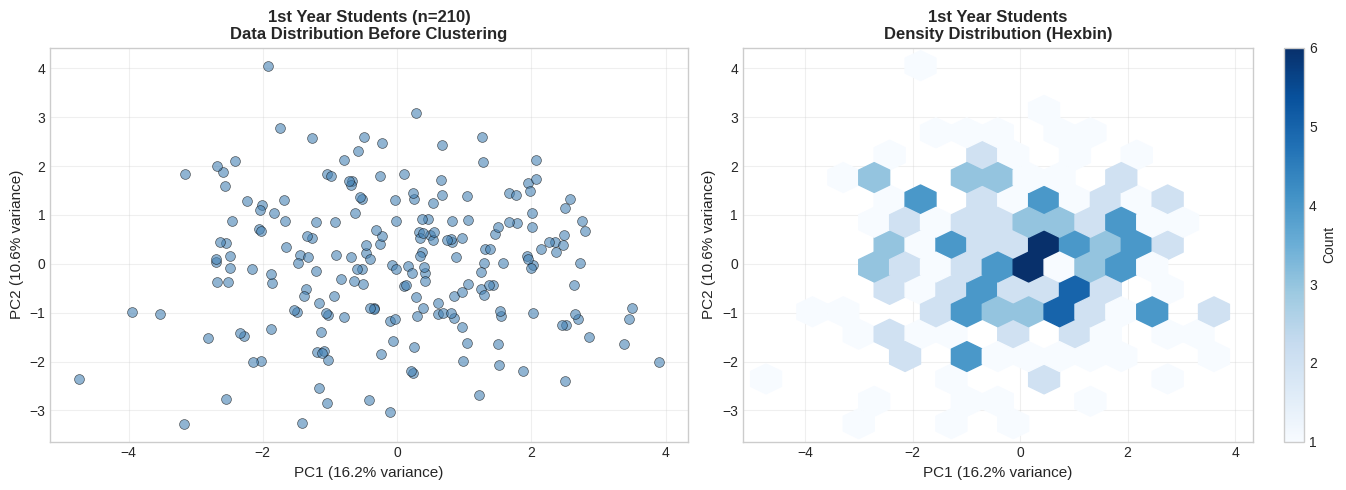


PCA Explained Variance:
   PC1: 16.2%
   PC2: 10.6%
   Total (2 components): 26.8%


In [9]:
# 1st Year - Data Shape Before Clustering
print("\n" + "-"*60)
print("1ST YEAR STUDENTS - DATA SHAPE")
print("-"*60)
X_pca_1y_pre, pca_1y_pre = visualize_data_before_clustering(X_1y_scaled, "1st Year Students", len(data_1y))


------------------------------------------------------------
2ND YEAR STUDENTS - DATA SHAPE
------------------------------------------------------------


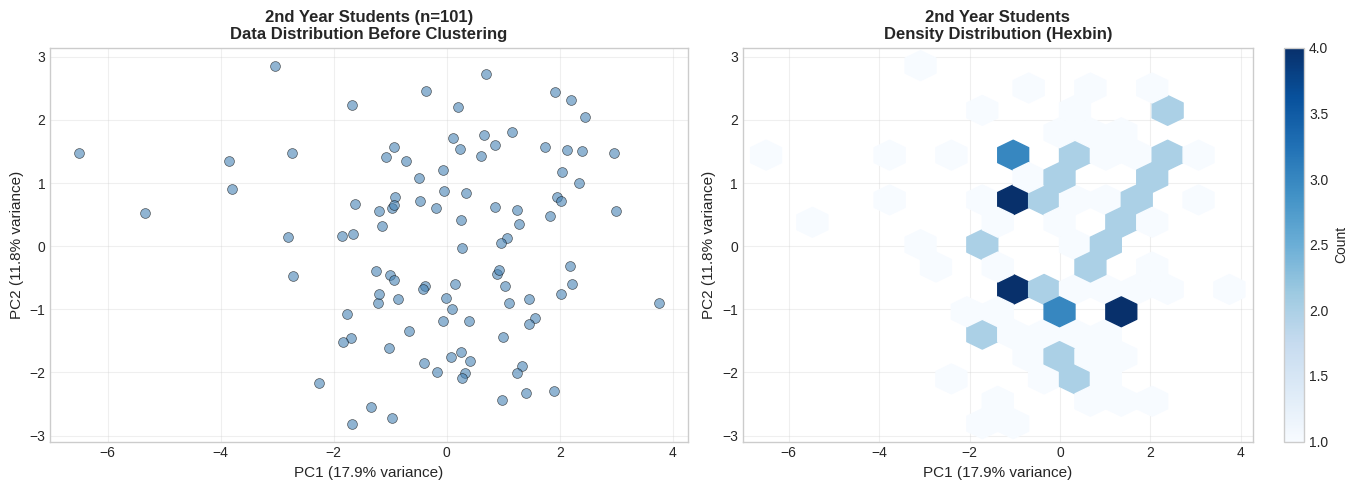


PCA Explained Variance:
   PC1: 17.9%
   PC2: 11.8%
   Total (2 components): 29.7%


In [10]:
# 2nd Year - Data Shape Before Clustering
print("\n" + "-"*60)
print("2ND YEAR STUDENTS - DATA SHAPE")
print("-"*60)
X_pca_2y_pre, pca_2y_pre = visualize_data_before_clustering(X_2y_scaled, "2nd Year Students", len(data_2y))


------------------------------------------------------------
3RD YEAR STUDENTS - DATA SHAPE
------------------------------------------------------------


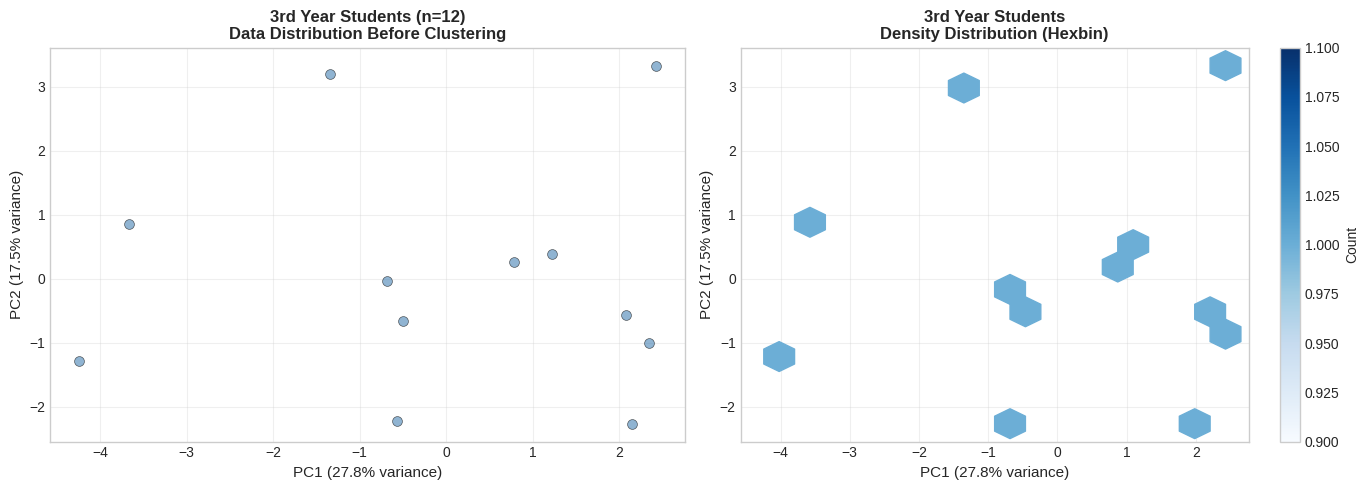


PCA Explained Variance:
   PC1: 27.8%
   PC2: 17.5%
   Total (2 components): 45.4%


In [11]:
# 3rd Year - Data Shape Before Clustering
print("\n" + "-"*60)
print("3RD YEAR STUDENTS - DATA SHAPE")
print("-"*60)
X_pca_3y_pre, pca_3y_pre = visualize_data_before_clustering(X_3y_scaled, "3rd Year Students", len(data_3y))

## 3. DBSCAN Parameter Optimization

In [12]:
# =============================================================================
# K-Distance Graph for Optimal Epsilon Selection
# =============================================================================

def plot_k_distance_graph(X_scaled, k, dataset_name):
    """
    Plot k-distance graph to find optimal epsilon value.
    The elbow point in the graph suggests a good eps value.
    """
    # Calculate distances to k-th nearest neighbor
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors.fit(X_scaled)
    distances, indices = neighbors.kneighbors(X_scaled)
    
    # Sort distances to k-th nearest neighbor
    k_distances = np.sort(distances[:, k-1])
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Full k-distance plot
    axes[0].plot(range(len(k_distances)), k_distances, 'b-', linewidth=1.5)
    axes[0].set_xlabel('Points sorted by distance', fontsize=11)
    axes[0].set_ylabel(f'{k}-th Nearest Neighbor Distance', fontsize=11)
    axes[0].set_title(f'{dataset_name}: K-Distance Graph (k={k})', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Zoomed view for elbow detection
    axes[1].plot(range(len(k_distances)), k_distances, 'b-', linewidth=1.5)
    axes[1].set_xlabel('Points sorted by distance', fontsize=11)
    axes[1].set_ylabel(f'{k}-th Nearest Neighbor Distance', fontsize=11)
    axes[1].set_title(f'{dataset_name}: K-Distance Graph (Zoomed)', fontsize=12, fontweight='bold')
    
    # Set y-limit to focus on elbow region
    y_95 = np.percentile(k_distances, 95)
    axes[1].set_ylim(0, y_95 * 1.2)
    axes[1].grid(True, alpha=0.3)
    
    # Add percentile reference lines
    for percentile in [50, 75, 90]:
        val = np.percentile(k_distances, percentile)
        axes[1].axhline(y=val, color='r', linestyle='--', alpha=0.5, 
                       label=f'{percentile}th percentile: {val:.2f}')
    axes[1].legend(loc='lower right', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Return statistics to help choose eps
    print(f"\nK-Distance Statistics for {dataset_name}:")
    print(f"   Min distance: {k_distances.min():.3f}")
    print(f"   25th percentile: {np.percentile(k_distances, 25):.3f}")
    print(f"   Median distance: {np.median(k_distances):.3f}")
    print(f"   75th percentile: {np.percentile(k_distances, 75):.3f}")
    print(f"   90th percentile: {np.percentile(k_distances, 90):.3f}")
    print(f"   Max distance: {k_distances.max():.3f}")
    
    return k_distances

# Rule of thumb: min_samples = 2 * dimensions (features)
min_samples_rule = 2 * len(common_features)
print(f"\nUsing min_samples rule of thumb: 2 x {len(common_features)} features = {min_samples_rule}")

# We'll use a slightly smaller value for better cluster detection
k_value = min(min_samples_rule, 5)  # Use 5 as a reasonable default
print(f"Using k = {k_value} for k-distance graph analysis")


Using min_samples rule of thumb: 2 x 17 features = 34
Using k = 5 for k-distance graph analysis



K-DISTANCE ANALYSIS FOR EPSILON SELECTION

------------------------------------------------------------
1ST YEAR STUDENTS
------------------------------------------------------------


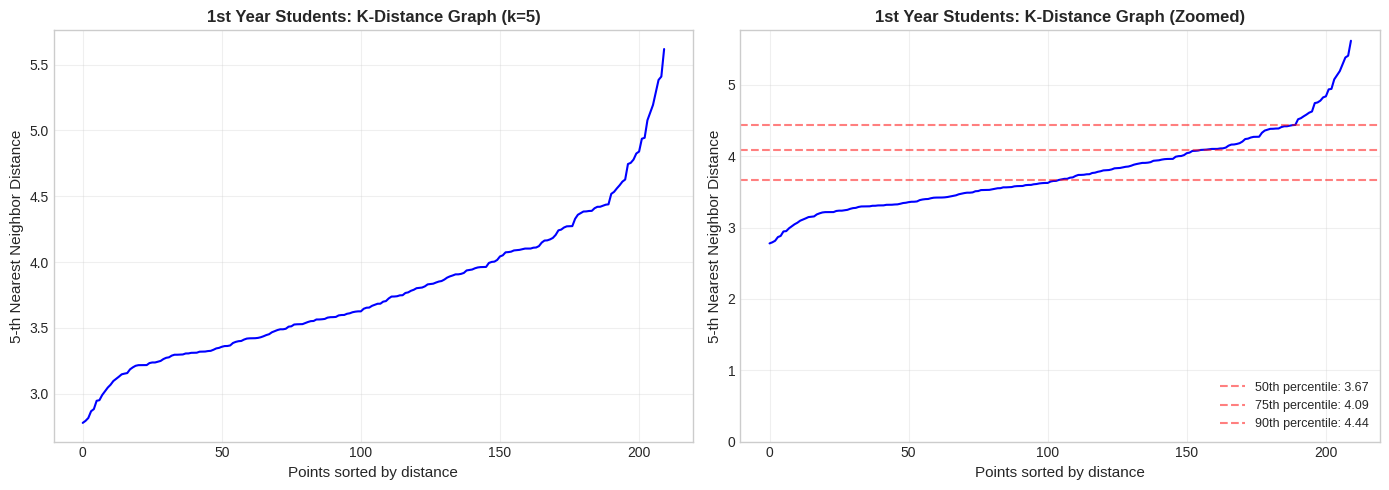


K-Distance Statistics for 1st Year Students:
   Min distance: 2.778
   25th percentile: 3.363
   Median distance: 3.671
   75th percentile: 4.092
   90th percentile: 4.436
   Max distance: 5.619


In [13]:
# =============================================================================
# Analyze K-Distance for Each Dataset
# =============================================================================

print("\n" + "="*80)
print("K-DISTANCE ANALYSIS FOR EPSILON SELECTION")
print("="*80)

# 1st Year
print("\n" + "-"*60)
print("1ST YEAR STUDENTS")
print("-"*60)
k_dist_1y = plot_k_distance_graph(X_1y_scaled, k_value, "1st Year Students")


------------------------------------------------------------
2ND YEAR STUDENTS
------------------------------------------------------------


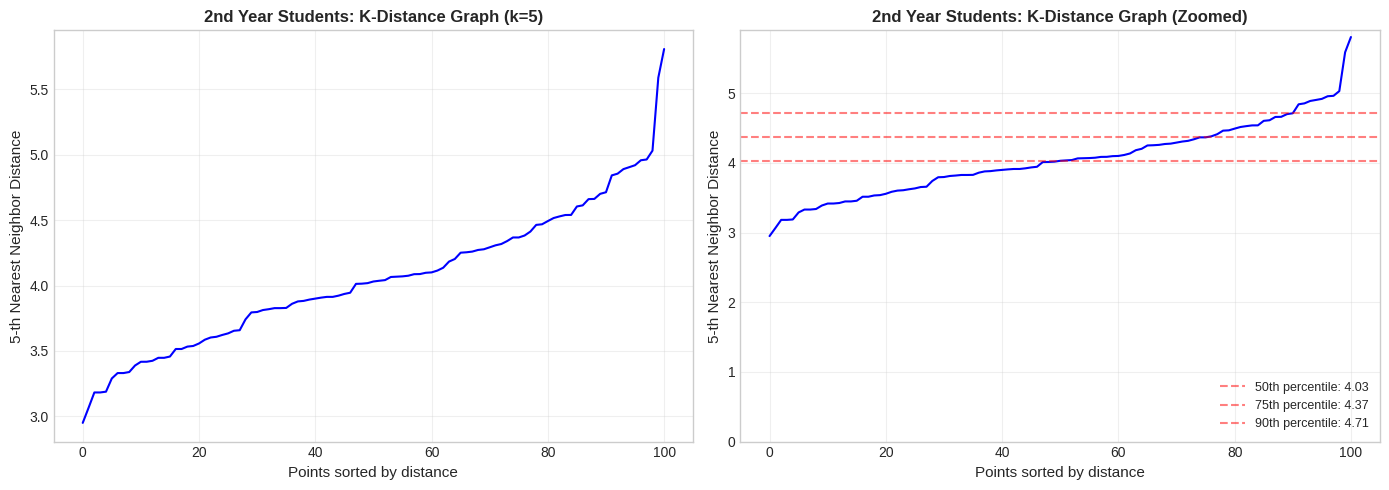


K-Distance Statistics for 2nd Year Students:
   Min distance: 2.950
   25th percentile: 3.635
   Median distance: 4.031
   75th percentile: 4.368
   90th percentile: 4.713
   Max distance: 5.808


In [14]:
# 2nd Year
print("\n" + "-"*60)
print("2ND YEAR STUDENTS")
print("-"*60)
k_dist_2y = plot_k_distance_graph(X_2y_scaled, k_value, "2nd Year Students")


------------------------------------------------------------
3RD YEAR STUDENTS
------------------------------------------------------------


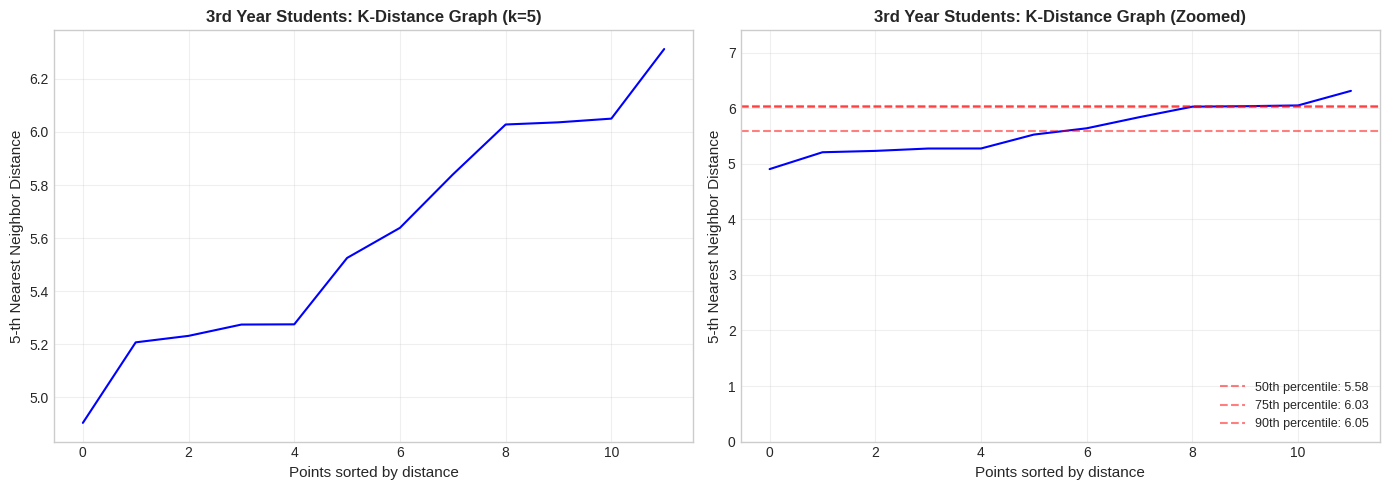


K-Distance Statistics for 3rd Year Students:
   Min distance: 4.904
   25th percentile: 5.264
   Median distance: 5.582
   75th percentile: 6.030
   90th percentile: 6.049
   Max distance: 6.312


In [15]:
# 3rd Year
print("\n" + "-"*60)
print("3RD YEAR STUDENTS")
print("-"*60)
k_dist_3y = plot_k_distance_graph(X_3y_scaled, k_value, "3rd Year Students")

## 4. DBSCAN Clustering Implementation

In [16]:
# =============================================================================
# Experimental Parameter Search for DBSCAN
# =============================================================================

def run_dbscan_experiment(X_scaled, dataset_name, n_samples):
    """
    Run DBSCAN with multiple combinations of eps and min_samples.
    Select optimal parameters based on experimental results:
    - Prioritize configurations with multiple clusters (>=2)
    - Prefer lower noise ratios (<50%)
    - Consider silhouette score for cluster quality
    
    Parameters are tuned independently for each dataset.
    """
    print(f"\n{'='*70}")
    print(f"EXPERIMENTAL PARAMETER SEARCH: {dataset_name}")
    print(f"{'='*70}")
    
    # Define parameter ranges based on dataset size
    # Smaller datasets need smaller min_samples
    if n_samples < 30:
        min_samples_range = [2, 3]
        eps_range = np.arange(1.0, 6.0, 0.5)
    elif n_samples < 80:
        min_samples_range = [2, 3, 4, 5]
        eps_range = np.arange(1.0, 5.5, 0.5)
    else:
        min_samples_range = [3, 4, 5, 6, 7]
        eps_range = np.arange(1.5, 5.5, 0.5)
    
    print(f"\nDataset size: {n_samples} samples")
    print(f"Testing eps values: {list(eps_range)}")
    print(f"Testing min_samples values: {min_samples_range}")
    print(f"Total configurations to test: {len(eps_range) * len(min_samples_range)}")
    
    all_results = []
    
    for min_samples in min_samples_range:
        for eps in eps_range:
            # Run DBSCAN
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels = dbscan.fit_predict(X_scaled)
            
            # Calculate metrics
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            noise_ratio = n_noise / len(labels) * 100
            n_clustered = n_samples - n_noise
            
            # Calculate clustering quality metrics
            silhouette, calinski, davies = np.nan, np.nan, np.nan
            if n_clusters >= 2:
                mask = labels != -1
                if mask.sum() > 1 and len(set(labels[mask])) > 1:
                    silhouette = silhouette_score(X_scaled[mask], labels[mask])
                    calinski = calinski_harabasz_score(X_scaled[mask], labels[mask])
                    davies = davies_bouldin_score(X_scaled[mask], labels[mask])
            
            all_results.append({
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'noise_ratio': noise_ratio,
                'n_clustered': n_clustered,
                'silhouette': silhouette,
                'calinski_harabasz': calinski,
                'davies_bouldin': davies,
                'labels': labels
            })
    
    # Display all results
    print(f"\n{'eps':<6} {'min_s':<7} {'Clusters':<9} {'Noise':<7} {'Noise%':<8} {'Clustered':<10} {'Silhouette':<11}")
    print("-" * 70)
    for r in all_results:
        sil_str = f"{r['silhouette']:.3f}" if not np.isnan(r['silhouette']) else "N/A"
        print(f"{r['eps']:<6.1f} {r['min_samples']:<7} {r['n_clusters']:<9} {r['n_noise']:<7} {r['noise_ratio']:<8.1f} {r['n_clustered']:<10} {sil_str:<11}")
    
    return all_results


def select_best_parameters(results, dataset_name, n_samples):
    """
    Select best parameters based on experimental results.
    
    Selection criteria (in order of priority):
    1. Must have at least 2 clusters
    2. Noise ratio should be reasonable (prefer < 50%, accept up to 70%)
    3. More clustered points is better
    4. Higher silhouette score is better
    """
    print(f"\n{'='*70}")
    print(f"PARAMETER SELECTION: {dataset_name}")
    print(f"{'='*70}")
    
    # Filter: must have at least 2 clusters
    valid = [r for r in results if r['n_clusters'] >= 2]
    
    if not valid:
        print("\nNo configuration produced 2+ clusters.")
        print("Selecting configuration with most clusters...")
        best = max(results, key=lambda x: (x['n_clusters'], -x['noise_ratio']))
        print(f"\nSelected: eps={best['eps']}, min_samples={best['min_samples']}")
        print(f"   Clusters: {best['n_clusters']}, Noise: {best['noise_ratio']:.1f}%")
        return best
    
    # Score each valid configuration
    for r in valid:
        # Base score from silhouette (0 if N/A)
        sil_score = r['silhouette'] if not np.isnan(r['silhouette']) else 0
        
        # Bonus for more clusters (up to a point)
        cluster_bonus = min(r['n_clusters'], 5) * 0.05
        
        # Bonus for more clustered points (as percentage)
        clustered_ratio = r['n_clustered'] / n_samples
        clustered_bonus = clustered_ratio * 0.3
        
        # Penalty for high noise
        if r['noise_ratio'] > 70:
            noise_penalty = 0.3
        elif r['noise_ratio'] > 50:
            noise_penalty = 0.15
        elif r['noise_ratio'] > 30:
            noise_penalty = 0.05
        else:
            noise_penalty = 0
        
        r['score'] = sil_score + cluster_bonus + clustered_bonus - noise_penalty
    
    # Select best
    best = max(valid, key=lambda x: x['score'])
    
    print(f"\nBest configuration found:")
    print(f"   eps = {best['eps']}")
    print(f"   min_samples = {best['min_samples']}")
    print(f"\nResults:")
    print(f"   Number of clusters: {best['n_clusters']}")
    print(f"   Noise points: {best['n_noise']} ({best['noise_ratio']:.1f}%)")
    print(f"   Clustered points: {best['n_clustered']} ({100-best['noise_ratio']:.1f}%)")
    if not np.isnan(best['silhouette']):
        print(f"   Silhouette Score: {best['silhouette']:.3f}")
    if not np.isnan(best['calinski_harabasz']):
        print(f"   Calinski-Harabasz Index: {best['calinski_harabasz']:.1f}")
    if not np.isnan(best['davies_bouldin']):
        print(f"   Davies-Bouldin Index: {best['davies_bouldin']:.3f}")
    
    # Show top 5 configurations
    sorted_valid = sorted(valid, key=lambda x: x['score'], reverse=True)[:5]
    print(f"\nTop 5 configurations:")
    print(f"{'Rank':<6} {'eps':<6} {'min_s':<7} {'Clusters':<9} {'Noise%':<8} {'Silhouette':<11} {'Score':<8}")
    print("-" * 60)
    for i, r in enumerate(sorted_valid, 1):
        sil_str = f"{r['silhouette']:.3f}" if not np.isnan(r['silhouette']) else "N/A"
        print(f"{i:<6} {r['eps']:<6.1f} {r['min_samples']:<7} {r['n_clusters']:<9} {r['noise_ratio']:<8.1f} {sil_str:<11} {r['score']:<8.3f}")
    
    return best

In [17]:
# =============================================================================
# Run Experimental Parameter Search - 1st Year
# =============================================================================

print("\n" + "="*80)
print("1ST YEAR STUDENTS - PARAMETER EXPERIMENT")
print("="*80)

results_1y = run_dbscan_experiment(X_1y_scaled, "1st Year Students", len(data_1y))


1ST YEAR STUDENTS - PARAMETER EXPERIMENT

EXPERIMENTAL PARAMETER SEARCH: 1st Year Students

Dataset size: 210 samples
Testing eps values: [np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]
Testing min_samples values: [3, 4, 5, 6, 7]
Total configurations to test: 40

eps    min_s   Clusters  Noise   Noise%   Clustered  Silhouette 
----------------------------------------------------------------------
1.5    3       0         210     100.0    0          N/A        
2.0    3       0         210     100.0    0          N/A        
2.5    3       2         204     97.1     6          0.302      
3.0    3       8         146     69.5     64         0.102      
3.5    3       1         68      32.4     142        N/A        
4.0    3       1         22      10.5     188        N/A        
4.5    3       1         8       3.8      202        N/A        
5.0    3       1         1       0.5      209        N/

In [18]:
# =============================================================================
# Run Experimental Parameter Search - 2nd Year
# =============================================================================

print("\n" + "="*80)
print("2ND YEAR STUDENTS - PARAMETER EXPERIMENT")
print("="*80)

results_2y = run_dbscan_experiment(X_2y_scaled, "2nd Year Students", len(data_2y))


2ND YEAR STUDENTS - PARAMETER EXPERIMENT

EXPERIMENTAL PARAMETER SEARCH: 2nd Year Students

Dataset size: 101 samples
Testing eps values: [np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]
Testing min_samples values: [3, 4, 5, 6, 7]
Total configurations to test: 40

eps    min_s   Clusters  Noise   Noise%   Clustered  Silhouette 
----------------------------------------------------------------------
1.5    3       0         101     100.0    0          N/A        
2.0    3       0         101     100.0    0          N/A        
2.5    3       1         98      97.0     3          N/A        
3.0    3       7         74      73.3     27         0.303      
3.5    3       3         46      45.5     55         0.124      
4.0    3       1         15      14.9     86         N/A        
4.5    3       1         5       5.0      96         N/A        
5.0    3       1         0       0.0      101        N/

In [19]:
# =============================================================================
# Run Experimental Parameter Search - 3rd Year
# =============================================================================

print("\n" + "="*80)
print("3RD YEAR STUDENTS - PARAMETER EXPERIMENT")
print("="*80)

results_3y = run_dbscan_experiment(X_3y_scaled, "3rd Year Students", len(data_3y))


3RD YEAR STUDENTS - PARAMETER EXPERIMENT

EXPERIMENTAL PARAMETER SEARCH: 3rd Year Students

Dataset size: 12 samples
Testing eps values: [np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0), np.float64(5.5)]
Testing min_samples values: [2, 3]
Total configurations to test: 20

eps    min_s   Clusters  Noise   Noise%   Clustered  Silhouette 
----------------------------------------------------------------------
1.0    2       0         12      100.0    0          N/A        
1.5    2       0         12      100.0    0          N/A        
2.0    2       0         12      100.0    0          N/A        
2.5    2       0         12      100.0    0          N/A        
3.0    2       0         12      100.0    0          N/A        
3.5    2       0         12      100.0    0          N/A        
4.0    2       2         7       58.3     5          0.274      
4.5    2       2         7     

## 5. Parameter Selection and Optimal DBSCAN Results

In [20]:
# =============================================================================
# Select Optimal Parameters for Each Dataset
# =============================================================================

# Each year gets its own optimal parameters based on experimental results
best_1y = select_best_parameters(results_1y, "1st Year Students", len(data_1y))
best_2y = select_best_parameters(results_2y, "2nd Year Students", len(data_2y))
best_3y = select_best_parameters(results_3y, "3rd Year Students", len(data_3y))

# Store selected parameters for each year
params_1y = {'eps': best_1y['eps'], 'min_samples': best_1y['min_samples']}
params_2y = {'eps': best_2y['eps'], 'min_samples': best_2y['min_samples']}
params_3y = {'eps': best_3y['eps'], 'min_samples': best_3y['min_samples']}

print("\n" + "="*70)
print("SELECTED PARAMETERS SUMMARY")
print("="*70)
print(f"\n{'Dataset':<20} {'eps':<10} {'min_samples':<15} {'Clusters':<10} {'Noise %':<10}")
print("-" * 65)
print(f"{'1st Year':<20} {params_1y['eps']:<10.1f} {params_1y['min_samples']:<15} {best_1y['n_clusters']:<10} {best_1y['noise_ratio']:<10.1f}")
print(f"{'2nd Year':<20} {params_2y['eps']:<10.1f} {params_2y['min_samples']:<15} {best_2y['n_clusters']:<10} {best_2y['noise_ratio']:<10.1f}")
print(f"{'3rd Year':<20} {params_3y['eps']:<10.1f} {params_3y['min_samples']:<15} {best_3y['n_clusters']:<10} {best_3y['noise_ratio']:<10.1f}")


PARAMETER SELECTION: 1st Year Students

Best configuration found:
   eps = 3.5
   min_samples = 5

Results:
   Number of clusters: 2
   Noise points: 78 (37.1%)
   Clustered points: 132 (62.9%)
   Silhouette Score: 0.108
   Calinski-Harabasz Index: 6.2
   Davies-Bouldin Index: 1.786

Top 5 configurations:
Rank   eps    min_s   Clusters  Noise%   Silhouette  Score   
------------------------------------------------------------
1      3.5    5       2         37.1     0.108       0.347   
2      3.5    6       2         40.0     0.113       0.343   
3      3.5    7       2         43.8     0.123       0.342   
4      3.0    3       8         69.5     0.102       0.294   
5      3.0    7       2         93.3     0.342       0.162   

PARAMETER SELECTION: 2nd Year Students

Best configuration found:
   eps = 3.5
   min_samples = 3

Results:
   Number of clusters: 3
   Noise points: 46 (45.5%)
   Clustered points: 55 (54.5%)
   Silhouette Score: 0.124
   Calinski-Harabasz Index: 5.6
   Dav

## 6. Visualization of Clustering Results

In [21]:
# =============================================================================
# Visualize Clustering Results using PCA
# =============================================================================

def visualize_dbscan_results(X_scaled, labels, eps, min_samples, dataset_name):
    """
    Visualize DBSCAN clustering results using PCA for dimensionality reduction.
    """
    # Apply PCA for visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Cluster visualization
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    
    colors = plt.cm.Set1(np.linspace(0, 1, max(n_clusters, 1)))
    
    for k, col in zip(sorted(unique_labels), ['gray'] + list(colors)):
        if k == -1:
            # Noise points
            col = 'lightgray'
            marker = 'x'
            label = f'Noise (n={sum(labels == k)})'
            alpha = 0.5
            s = 30
        else:
            marker = 'o'
            label = f'Cluster {k} (n={sum(labels == k)})'
            alpha = 0.7
            s = 50
        
        class_mask = labels == k
        axes[0].scatter(X_pca[class_mask, 0], X_pca[class_mask, 1],
                       c=[col], marker=marker, s=s, alpha=alpha, label=label, edgecolors='black', linewidth=0.5)
    
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
    axes[0].set_title(f'{dataset_name}\nDBSCAN Clustering (eps={eps}, min_samples={min_samples})', 
                     fontsize=12, fontweight='bold')
    axes[0].legend(loc='best', fontsize=9)
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Cluster size distribution
    cluster_counts = pd.Series(labels).value_counts().sort_index()
    colors_bar = ['lightgray' if idx == -1 else plt.cm.Set1(idx/max(n_clusters, 1)) 
                  for idx in cluster_counts.index]
    
    bars = axes[1].bar(range(len(cluster_counts)), cluster_counts.values, color=colors_bar, edgecolor='black')
    axes[1].set_xticks(range(len(cluster_counts)))
    axes[1].set_xticklabels([f'Noise' if idx == -1 else f'Cluster {idx}' for idx in cluster_counts.index], 
                            rotation=45, ha='right')
    axes[1].set_xlabel('Cluster', fontsize=11)
    axes[1].set_ylabel('Number of Points', fontsize=11)
    axes[1].set_title(f'{dataset_name}\nCluster Size Distribution', fontsize=12, fontweight='bold')
    
    # Add count labels on bars
    for bar, count in zip(bars, cluster_counts.values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                    str(count), ha='center', va='bottom', fontsize=10)
    
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    return X_pca, pca

print("\n" + "="*80)
print("CLUSTERING VISUALIZATION")
print("="*80)


CLUSTERING VISUALIZATION



------------------------------------------------------------
1ST YEAR STUDENTS - VISUALIZATION
------------------------------------------------------------


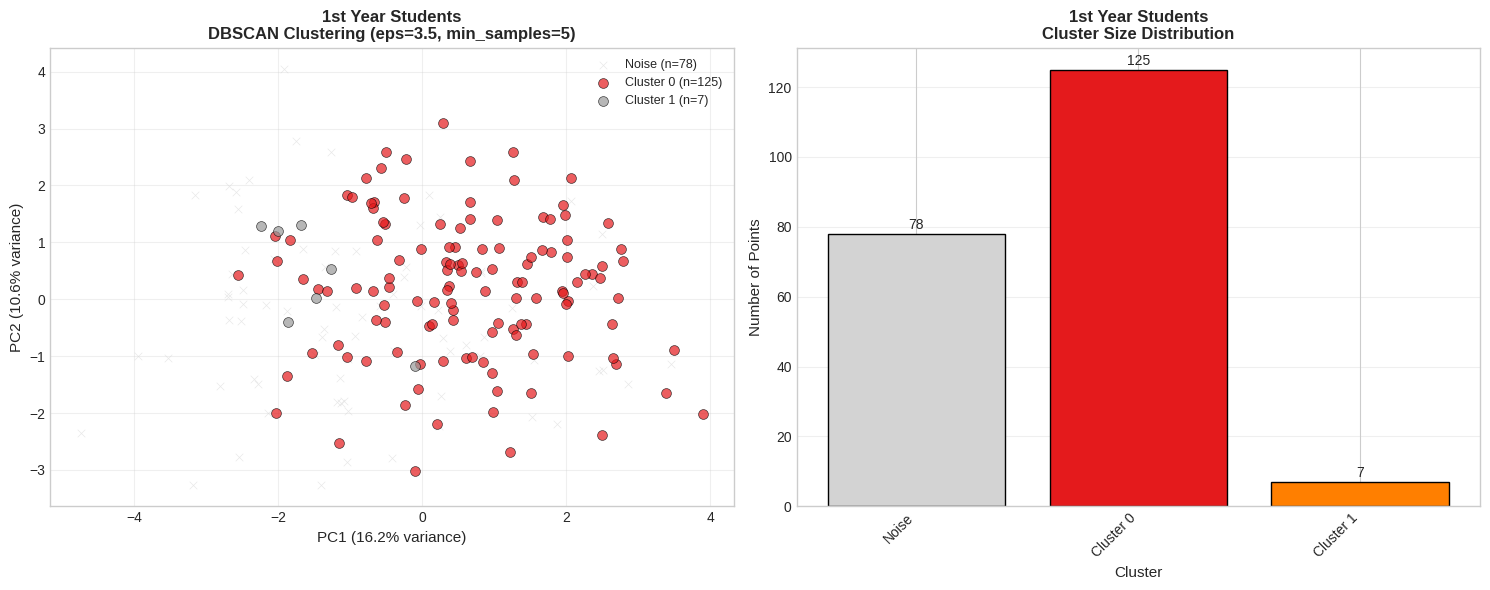

In [22]:
# Visualize 1st Year Results
print("\n" + "-"*60)
print("1ST YEAR STUDENTS - VISUALIZATION")
print("-"*60)
X_pca_1y, pca_1y = visualize_dbscan_results(X_1y_scaled, best_1y['labels'], 
                                             params_1y['eps'], params_1y['min_samples'], 
                                             "1st Year Students")


------------------------------------------------------------
2ND YEAR STUDENTS - VISUALIZATION
------------------------------------------------------------


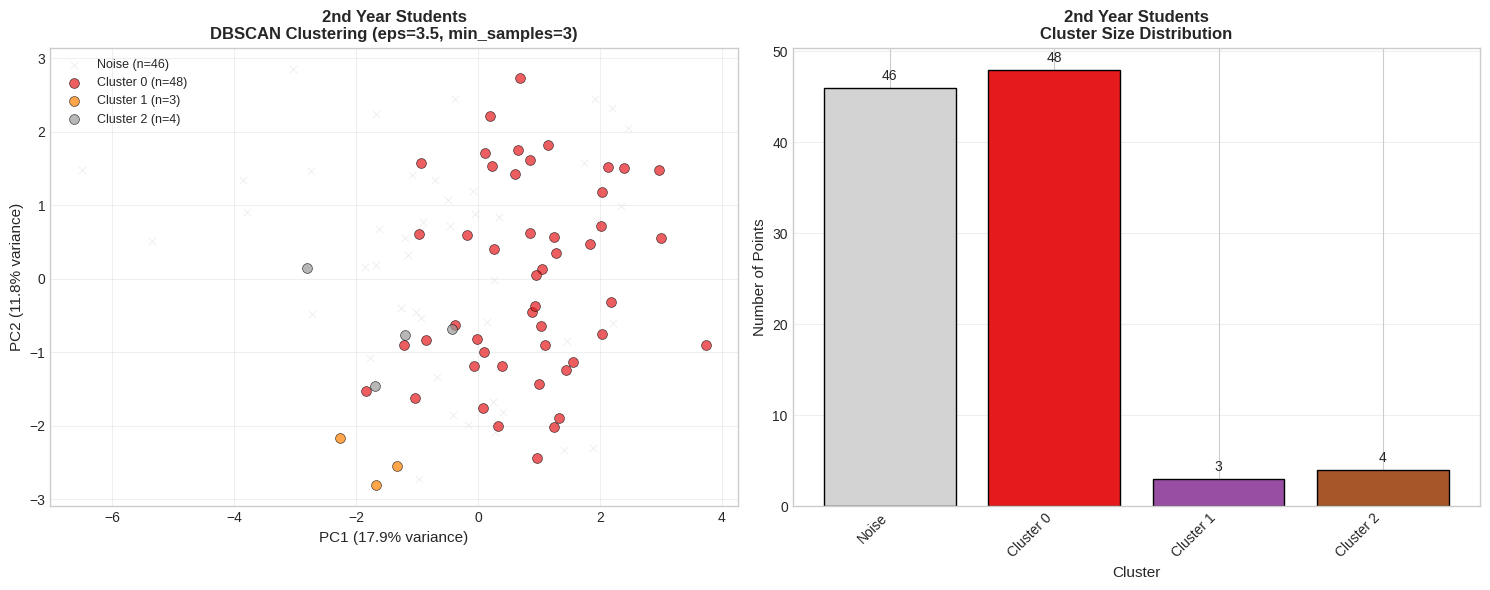

In [23]:
# Visualize 2nd Year Results
print("\n" + "-"*60)
print("2ND YEAR STUDENTS - VISUALIZATION")
print("-"*60)
X_pca_2y, pca_2y = visualize_dbscan_results(X_2y_scaled, best_2y['labels'], 
                                             params_2y['eps'], params_2y['min_samples'], 
                                             "2nd Year Students")


------------------------------------------------------------
3RD YEAR STUDENTS - VISUALIZATION
------------------------------------------------------------


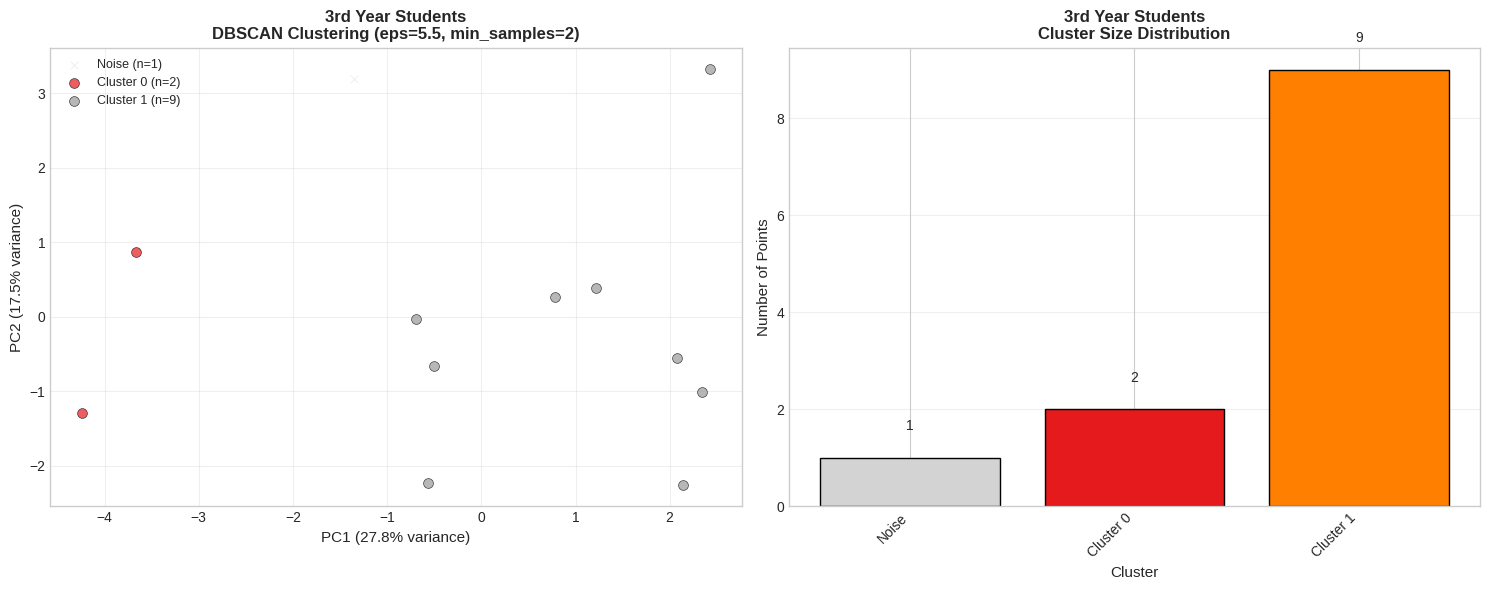

In [24]:
# Visualize 3rd Year Results
print("\n" + "-"*60)
print("3RD YEAR STUDENTS - VISUALIZATION")
print("-"*60)
X_pca_3y, pca_3y = visualize_dbscan_results(X_3y_scaled, best_3y['labels'], 
                                             params_3y['eps'], params_3y['min_samples'], 
                                             "3rd Year Students")

## 7. Cluster Profiling and Interpretation

In [25]:
# =============================================================================
# Cluster Profiling Function
# =============================================================================

def profile_clusters(df, features, labels, dataset_name):
    """
    Create detailed profiles of each cluster.
    """
    print(f"\n{'='*70}")
    print(f"CLUSTER PROFILING: {dataset_name}")
    print(f"{'='*70}")
    
    df_analysis = df[features].copy()
    df_analysis['Cluster'] = labels
    
    # Overall statistics by cluster
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    if n_clusters == 0:
        print("\nNo clusters formed - all points classified as noise.")
        return None
    
    print(f"\nNumber of clusters: {n_clusters}")
    print(f"Noise points: {sum(labels == -1)}")
    
    # Calculate cluster means for each feature
    cluster_profiles = df_analysis.groupby('Cluster').mean()
    
    # Display cluster profiles
    print(f"\nCluster Centers (Mean values):")
    display(cluster_profiles.round(2))
    
    # Identify distinguishing features for each cluster
    print(f"\nKey Distinguishing Features by Cluster:")
    overall_mean = df_analysis[features].mean()
    
    for cluster in sorted(set(labels)):
        if cluster == -1:
            continue
        print(f"\n  Cluster {cluster}:")
        cluster_mean = cluster_profiles.loc[cluster]
        
        # Find features that differ most from overall mean
        diff = (cluster_mean - overall_mean).abs().sort_values(ascending=False)
        top_features = diff.head(5)
        
        for feat in top_features.index:
            direction = "Higher" if cluster_mean[feat] > overall_mean[feat] else "Lower"
            print(f"    - {feat}: {direction} than average ({cluster_mean[feat]:.2f} vs {overall_mean[feat]:.2f})")
    
    return cluster_profiles

# Profile clusters for each year
profile_1y = profile_clusters(data_1y, common_features, best_1y['labels'], "1st Year Students")


CLUSTER PROFILING: 1st Year Students

Number of clusters: 2
Noise points: 78

Cluster Centers (Mean values):


,gender,bac_specialty,study_hours_per_week,preferred_study_place,preferred_study_time,learning_methods,study_resources,uses_planner,english_level,programming_level,computer_science_level,mathematics_level,motivation_level,sleep_hours,stress_management,program_satisfaction,external_activities
Cluster,,,,,,,,,,,,,,,,,
-1,0.40,0.67,1.24,2.12,0.42,24.85,20.90,0.40,6.74,5.83,5.49,6.09,3.13,1.50,2.79,2.31,0.51
0,0.50,0.50,1.14,2.35,0.17,27.14,20.16,0.38,7.58,6.95,6.90,6.88,3.69,1.15,3.14,2.58,0.63
1,0.14,0.86,0.86,0.29,0.71,12.43,11.57,0.29,7.00,6.00,5.71,5.71,2.71,1.29,2.71,1.86,0.00



Key Distinguishing Features by Cluster:

  Cluster 0:
    - learning_methods: Higher than average (27.14 vs 25.80)
    - computer_science_level: Higher than average (6.90 vs 6.34)
    - programming_level: Higher than average (6.95 vs 6.50)
    - mathematics_level: Higher than average (6.88 vs 6.55)
    - english_level: Higher than average (7.58 vs 7.25)

  Cluster 1:
    - learning_methods: Lower than average (12.43 vs 25.80)
    - study_resources: Lower than average (11.57 vs 20.15)
    - preferred_study_place: Lower than average (0.29 vs 2.20)
    - mathematics_level: Lower than average (5.71 vs 6.55)
    - motivation_level: Lower than average (2.71 vs 3.45)


In [26]:
# Profile 2nd Year clusters
profile_2y = profile_clusters(data_2y, common_features, best_2y['labels'], "2nd Year Students")


CLUSTER PROFILING: 2nd Year Students

Number of clusters: 3
Noise points: 46

Cluster Centers (Mean values):


,gender,bac_specialty,study_hours_per_week,preferred_study_place,preferred_study_time,learning_methods,study_resources,uses_planner,english_level,programming_level,computer_science_level,mathematics_level,motivation_level,sleep_hours,stress_management,program_satisfaction,external_activities
Cluster,,,,,,,,,,,,,,,,,
-1,0.39,0.78,0.91,1.09,0.46,26.98,17.91,0.46,7.41,6.67,6.61,6.37,3.24,0.37,3.09,2.50,0.57
0,0.52,0.19,0.33,1.65,0.23,17.44,17.58,0.23,8.00,7.29,7.25,7.19,3.52,0.25,3.27,2.73,0.77
1,0.00,2.00,4.67,2.00,0.00,22.00,4.00,1.00,7.00,6.67,7.33,7.67,3.67,0.00,3.00,2.33,0.00
2,0.00,0.00,2.25,2.00,0.00,33.75,11.25,0.00,7.00,7.00,6.50,6.50,2.50,0.00,3.00,2.00,0.00



Key Distinguishing Features by Cluster:

  Cluster 0:
    - learning_methods: Lower than average (17.44 vs 22.56)
    - study_resources: Higher than average (17.58 vs 17.08)
    - study_hours_per_week: Lower than average (0.33 vs 0.80)
    - mathematics_level: Higher than average (7.19 vs 6.80)
    - english_level: Higher than average (8.00 vs 7.66)

  Cluster 1:
    - study_resources: Lower than average (4.00 vs 17.08)
    - study_hours_per_week: Higher than average (4.67 vs 0.80)
    - bac_specialty: Higher than average (2.00 vs 0.50)
    - mathematics_level: Higher than average (7.67 vs 6.80)
    - english_level: Lower than average (7.00 vs 7.66)

  Cluster 2:
    - learning_methods: Higher than average (33.75 vs 22.56)
    - study_resources: Lower than average (11.25 vs 17.08)
    - study_hours_per_week: Higher than average (2.25 vs 0.80)
    - motivation_level: Lower than average (2.50 vs 3.36)
    - english_level: Lower than average (7.00 vs 7.66)


In [27]:
# Profile 3rd Year clusters
profile_3y = profile_clusters(data_3y, common_features, best_3y['labels'], "3rd Year Students")


CLUSTER PROFILING: 3rd Year Students

Number of clusters: 2
Noise points: 1

Cluster Centers (Mean values):


,gender,bac_specialty,study_hours_per_week,preferred_study_place,preferred_study_time,learning_methods,study_resources,uses_planner,english_level,programming_level,computer_science_level,mathematics_level,motivation_level,sleep_hours,stress_management,program_satisfaction,external_activities
Cluster,,,,,,,,,,,,,,,,,
-1,1.00,1.00,0.00,0.00,1.00,9.00,1.00,0.00,7.00,7.00,7.00,6.00,3.00,0.00,3.00,2.00,0.00
0,0.50,1.00,0.00,2.00,0.00,7.50,5.50,1.00,7.00,3.50,5.00,3.50,2.00,0.50,1.50,1.50,0.50
1,0.22,0.22,0.78,1.67,0.11,4.44,4.22,0.56,8.22,7.56,7.56,7.56,3.11,0.33,3.11,2.67,0.67



Key Distinguishing Features by Cluster:

  Cluster 0:
    - programming_level: Lower than average (3.50 vs 6.83)
    - mathematics_level: Lower than average (3.50 vs 6.75)
    - learning_methods: Higher than average (7.50 vs 5.33)
    - computer_science_level: Lower than average (5.00 vs 7.08)
    - stress_management: Lower than average (1.50 vs 2.83)

  Cluster 1:
    - learning_methods: Lower than average (4.44 vs 5.33)
    - mathematics_level: Higher than average (7.56 vs 6.75)
    - programming_level: Higher than average (7.56 vs 6.83)
    - computer_science_level: Higher than average (7.56 vs 7.08)
    - english_level: Higher than average (8.22 vs 7.92)


## 8. DBSCAN Suitability Assessment

In [28]:
# =============================================================================
# Comprehensive Suitability Assessment
# =============================================================================

def assess_dbscan_suitability(X_scaled, results, best_result, dataset_name, n_samples):
    """
    Assess whether DBSCAN is suitable for the given dataset.
    
    Criteria for suitability:
    1. Forms meaningful clusters (not all noise or single cluster)
    2. Reasonable noise ratio (typically 5-30%)
    3. Good silhouette score (> 0.25 is acceptable, > 0.5 is good)
    4. Cluster sizes are reasonably balanced
    """
    print(f"\n{'='*70}")
    print(f"DBSCAN SUITABILITY ASSESSMENT: {dataset_name}")
    print(f"{'='*70}")
    
    assessment = {
        'dataset': dataset_name,
        'n_samples': n_samples,
        'issues': [],
        'positives': [],
        'recommendation': '',
        'alternative_suggestions': []
    }
    
    n_clusters = best_result['n_clusters']
    noise_ratio = best_result['noise_ratio']
    silhouette = best_result['silhouette']
    labels = best_result['labels']
    
    print(f"\nDataset Statistics:")
    print(f"   - Sample size: {n_samples}")
    print(f"   - Clusters found: {n_clusters}")
    print(f"   - Noise ratio: {noise_ratio:.1f}%")
    print(f"   - Silhouette score: {silhouette:.3f}" if not np.isnan(silhouette) else "   - Silhouette score: N/A")
    
    # Assessment criteria
    print(f"\nAssessment Criteria:")
    
    # 1. Check number of clusters
    print(f"\n   1. Cluster Formation:")
    if n_clusters == 0:
        print(f"      FAIL: No clusters formed (all points are noise)")
        assessment['issues'].append("No meaningful clusters formed")
    elif n_clusters == 1:
        print(f"      WARNING: Only 1 cluster formed")
        assessment['issues'].append("Only single cluster detected")
    else:
        print(f"      PASS: {n_clusters} clusters formed")
        assessment['positives'].append(f"{n_clusters} distinct clusters identified")
    
    # 2. Check noise ratio
    print(f"\n   2. Noise Ratio:")
    if noise_ratio > 50:
        print(f"      FAIL: Noise ratio too high ({noise_ratio:.1f}%)")
        assessment['issues'].append(f"High noise ratio ({noise_ratio:.1f}%)")
    elif noise_ratio > 30:
        print(f"      WARNING: Noise ratio is elevated ({noise_ratio:.1f}%)")
        assessment['issues'].append(f"Elevated noise ratio ({noise_ratio:.1f}%)")
    elif noise_ratio < 5 and n_clusters > 0:
        print(f"      WARNING: Very low noise ratio ({noise_ratio:.1f}%) - eps might be too large")
        assessment['issues'].append("Very low noise ratio may indicate over-smoothing")
    else:
        print(f"      PASS: Noise ratio is reasonable ({noise_ratio:.1f}%)")
        assessment['positives'].append(f"Reasonable noise ratio ({noise_ratio:.1f}%)")
    
    # 3. Check silhouette score
    print(f"\n   3. Clustering Quality (Silhouette Score):")
    if np.isnan(silhouette):
        print(f"      FAIL: Cannot calculate silhouette score")
        assessment['issues'].append("Clustering quality cannot be measured")
    elif silhouette < 0:
        print(f"      FAIL: Negative silhouette ({silhouette:.3f}) - poor cluster separation")
        assessment['issues'].append(f"Poor cluster separation (silhouette={silhouette:.3f})")
    elif silhouette < 0.25:
        print(f"      WARNING: Low silhouette score ({silhouette:.3f})")
        assessment['issues'].append(f"Weak cluster structure (silhouette={silhouette:.3f})")
    elif silhouette < 0.5:
        print(f"      PASS: Acceptable silhouette score ({silhouette:.3f})")
        assessment['positives'].append(f"Acceptable cluster quality (silhouette={silhouette:.3f})")
    else:
        print(f"      PASS: Good silhouette score ({silhouette:.3f})")
        assessment['positives'].append(f"Good cluster quality (silhouette={silhouette:.3f})")
    
    # 4. Check sample size adequacy
    print(f"\n   4. Sample Size Adequacy:")
    if n_samples < 50:
        print(f"      FAIL: Sample size too small ({n_samples}) for reliable DBSCAN")
        assessment['issues'].append(f"Small sample size ({n_samples})")
    elif n_samples < 100:
        print(f"      WARNING: Small sample size ({n_samples}) may affect reliability")
        assessment['issues'].append(f"Limited sample size ({n_samples})")
    else:
        print(f"      PASS: Adequate sample size ({n_samples})")
        assessment['positives'].append(f"Adequate sample size ({n_samples})")
    
    # 5. Check cluster balance
    print(f"\n   5. Cluster Balance:")
    if n_clusters > 1:
        cluster_sizes = [sum(labels == i) for i in range(n_clusters)]
        size_ratio = max(cluster_sizes) / max(min(cluster_sizes), 1)
        if size_ratio > 10:
            print(f"      WARNING: Highly imbalanced clusters (ratio {size_ratio:.1f}:1)")
            assessment['issues'].append(f"Imbalanced cluster sizes")
        else:
            print(f"      PASS: Reasonably balanced clusters (ratio {size_ratio:.1f}:1)")
            assessment['positives'].append("Balanced cluster sizes")
    
    # Overall recommendation
    print(f"\n" + "="*70)
    print("OVERALL RECOMMENDATION")
    print("="*70)
    
    n_critical_issues = sum(1 for i in assessment['issues'] if 'No meaningful' in i or 'all points' in i.lower())
    n_warnings = len(assessment['issues']) - n_critical_issues
    
    if n_critical_issues >= 2 or (n_clusters == 0):
        suitability = "NOT SUITABLE"
        assessment['recommendation'] = "DBSCAN is NOT recommended for this dataset"
        print(f"\nVERDICT: DBSCAN is NOT SUITABLE for {dataset_name}")
        print(f"\n   Critical issues found: {n_critical_issues}")
        print(f"   Warnings: {n_warnings}")
        assessment['alternative_suggestions'] = [
            "K-Means: Better for globular clusters with known k",
            "Hierarchical Clustering: Good for exploring different cluster levels",
            "Gaussian Mixture Models: Handles varying cluster shapes and sizes",
            "HDBSCAN: Adaptive DBSCAN that handles varying densities"
        ]
    elif n_critical_issues == 1 or n_warnings >= 3:
        suitability = "MARGINALLY SUITABLE"
        assessment['recommendation'] = "DBSCAN shows limited effectiveness"
        print(f"\nVERDICT: DBSCAN is MARGINALLY SUITABLE for {dataset_name}")
        print(f"\n   Issues to consider: {len(assessment['issues'])}")
        assessment['alternative_suggestions'] = [
            "Consider trying HDBSCAN for better handling of varying densities",
            "K-Means might provide more stable results"
        ]
    else:
        suitability = "SUITABLE"
        assessment['recommendation'] = "DBSCAN is appropriate for this dataset"
        print(f"\nVERDICT: DBSCAN is SUITABLE for {dataset_name}")
    
    # List issues
    if assessment['issues']:
        print(f"\nIssues:")
        for issue in assessment['issues']:
            print(f"   - {issue}")
    
    # List positives
    if assessment['positives']:
        print(f"\nPositives:")
        for positive in assessment['positives']:
            print(f"   - {positive}")
    
    # Alternative suggestions
    if assessment['alternative_suggestions']:
        print(f"\nAlternative Clustering Methods to Consider:")
        for suggestion in assessment['alternative_suggestions']:
            print(f"   - {suggestion}")
    
    assessment['suitability'] = suitability
    return assessment

# Assess suitability for each dataset
assessment_1y = assess_dbscan_suitability(X_1y_scaled, results_1y, best_1y, "1st Year Students", len(data_1y))


DBSCAN SUITABILITY ASSESSMENT: 1st Year Students

Dataset Statistics:
   - Sample size: 210
   - Clusters found: 2
   - Noise ratio: 37.1%
   - Silhouette score: 0.108

Assessment Criteria:

   1. Cluster Formation:
      PASS: 2 clusters formed

   2. Noise Ratio:

   3. Clustering Quality (Silhouette Score):

   4. Sample Size Adequacy:
      PASS: Adequate sample size (210)

   5. Cluster Balance:

OVERALL RECOMMENDATION

VERDICT: DBSCAN is MARGINALLY SUITABLE for 1st Year Students

   Issues to consider: 3

Issues:
   - Elevated noise ratio (37.1%)
   - Weak cluster structure (silhouette=0.108)
   - Imbalanced cluster sizes

Positives:
   - 2 distinct clusters identified
   - Adequate sample size (210)

Alternative Clustering Methods to Consider:
   - Consider trying HDBSCAN for better handling of varying densities
   - K-Means might provide more stable results


In [29]:
# Assess 2nd Year
assessment_2y = assess_dbscan_suitability(X_2y_scaled, results_2y, best_2y, "2nd Year Students", len(data_2y))


DBSCAN SUITABILITY ASSESSMENT: 2nd Year Students

Dataset Statistics:
   - Sample size: 101
   - Clusters found: 3
   - Noise ratio: 45.5%
   - Silhouette score: 0.124

Assessment Criteria:

   1. Cluster Formation:
      PASS: 3 clusters formed

   2. Noise Ratio:

   3. Clustering Quality (Silhouette Score):

   4. Sample Size Adequacy:
      PASS: Adequate sample size (101)

   5. Cluster Balance:

OVERALL RECOMMENDATION

VERDICT: DBSCAN is MARGINALLY SUITABLE for 2nd Year Students

   Issues to consider: 3

Issues:
   - Elevated noise ratio (45.5%)
   - Weak cluster structure (silhouette=0.124)
   - Imbalanced cluster sizes

Positives:
   - 3 distinct clusters identified
   - Adequate sample size (101)

Alternative Clustering Methods to Consider:
   - Consider trying HDBSCAN for better handling of varying densities
   - K-Means might provide more stable results


In [30]:
# Assess 3rd Year
assessment_3y = assess_dbscan_suitability(X_3y_scaled, results_3y, best_3y, "3rd Year Students", len(data_3y))


DBSCAN SUITABILITY ASSESSMENT: 3rd Year Students

Dataset Statistics:
   - Sample size: 12
   - Clusters found: 2
   - Noise ratio: 8.3%
   - Silhouette score: 0.214

Assessment Criteria:

   1. Cluster Formation:
      PASS: 2 clusters formed

   2. Noise Ratio:
      PASS: Noise ratio is reasonable (8.3%)

   3. Clustering Quality (Silhouette Score):

   4. Sample Size Adequacy:
      FAIL: Sample size too small (12) for reliable DBSCAN

   5. Cluster Balance:
      PASS: Reasonably balanced clusters (ratio 4.5:1)

OVERALL RECOMMENDATION

VERDICT: DBSCAN is SUITABLE for 3rd Year Students

Issues:
   - Weak cluster structure (silhouette=0.214)
   - Small sample size (12)

Positives:
   - 2 distinct clusters identified
   - Reasonable noise ratio (8.3%)
   - Balanced cluster sizes


## 9. Summary and Conclusions

In [31]:
# =============================================================================
# Final Summary Report
# =============================================================================

print("\n" + "="*80)
print("DBSCAN CLUSTERING ANALYSIS - FINAL SUMMARY REPORT")
print("="*80)

print("\n" + "-"*80)
print("PARAMETER SELECTION SUMMARY (Experimental Approach)")
print("-"*80)

print(f"\n{'Dataset':<20} {'eps':<10} {'min_samples':<15} {'Clusters':<12} {'Noise %':<12} {'Silhouette':<12}")
print("-" * 81)

for name, params, best in [
    ("1st Year", params_1y, best_1y),
    ("2nd Year", params_2y, best_2y),
    ("3rd Year", params_3y, best_3y)
]:
    sil_str = f"{best['silhouette']:.3f}" if not np.isnan(best['silhouette']) else "N/A"
    print(f"{name:<20} {params['eps']:<10.1f} {params['min_samples']:<15} {best['n_clusters']:<12} {best['noise_ratio']:<12.1f} {sil_str:<12}")

print("\n" + "-"*80)
print("SUITABILITY SUMMARY")
print("-"*80)

for name, assessment in [
    ("1st Year Students", assessment_1y),
    ("2nd Year Students", assessment_2y),
    ("3rd Year Students", assessment_3y)
]:
    status = "[+]" if assessment['suitability'] == "SUITABLE" else "[~]" if assessment['suitability'] == "MARGINALLY SUITABLE" else "[-]"
    print(f"\n{status} {name}: {assessment['suitability']}")
    print(f"    {assessment['recommendation']}")

print("\n" + "-"*80)
print("INTERPRETATION")
print("-"*80)
print("""
Parameter Selection Rationale:
   - Parameters were selected through experimental search across multiple combinations
   - Each year level has independently optimized eps and min_samples values
   - Selection criteria prioritized: 2+ clusters, reasonable noise ratio, silhouette score

Metric Interpretation:
   - Silhouette Score: Measures cluster cohesion and separation
     > 0.5: Strong structure | 0.25-0.5: Reasonable structure | < 0.25: Weak/no structure
   - Noise Ratio: Percentage of points not assigned to any cluster
     < 30%: Good | 30-50%: Acceptable | > 50%: High noise indicates poor fit

Suitability Factors:
   - Uniform data distribution limits density-based cluster detection
   - Small sample sizes (especially 3rd year with n=12) reduce reliability
   - Encoded categorical features create discrete rather than continuous density patterns
""")


DBSCAN CLUSTERING ANALYSIS - FINAL SUMMARY REPORT

--------------------------------------------------------------------------------
PARAMETER SELECTION SUMMARY (Experimental Approach)
--------------------------------------------------------------------------------

Dataset              eps        min_samples     Clusters     Noise %      Silhouette  
---------------------------------------------------------------------------------
1st Year             3.5        5               2            37.1         0.108       
2nd Year             3.5        3               3            45.5         0.124       
3rd Year             5.5        2               2            8.3          0.214       

--------------------------------------------------------------------------------
SUITABILITY SUMMARY
--------------------------------------------------------------------------------

[~] 1st Year Students: MARGINALLY SUITABLE
    DBSCAN shows limited effectiveness

[~] 2nd Year Students: MARGINALLY SU